In [1]:
import torch

In [2]:
from helper import plot_map, from_upper_triu

In [3]:
# to ensure the local, forked ledidi is used
# not the one installed using pip

import sys
sys.path.insert(0, "/home1/smaruj/ledidi")  # Add the directory where "ledidi" is located
from ledidi.pruning import greedy_pruning

In [4]:
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cuda:0


In [6]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_735182/ipykernel_2820291/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_f

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [7]:
# original seq, no modifications
X = torch.load("/scratch1/smaruj/ledidi_targets/constant_boundary_background/X_no_mod.pt", weights_only=True, map_location=device)

In [9]:
# edited sequence, with modifications
X_hat = torch.load("/scratch1/smaruj/ledidi_targets/constant_boundary_background/X_with_mod.pt", weights_only=True, map_location=device)

In [10]:
X_hat_prunned, diff_idxs, all_values = greedy_pruning(model, X, X_hat, input_mask_slices_0=[256], 
                                output_loss=torch.nn.L1Loss(reduction='sum'),
                                X1=None, X1_hat=None, input_mask_slices_1=None,
                                threshold=1e3, fast_threshold=100, cropping_applied=32,
                                semifreddo_temp_output_path="/scratch1/smaruj/ledidi_targets/constant_boundary_background/tower_out.pt", 
                                verbose=True)

Initial number of differences to consider for pruning: 964
Fast pruning phase removed 742 edits out of 964.
222 edits left for greedy pruning.


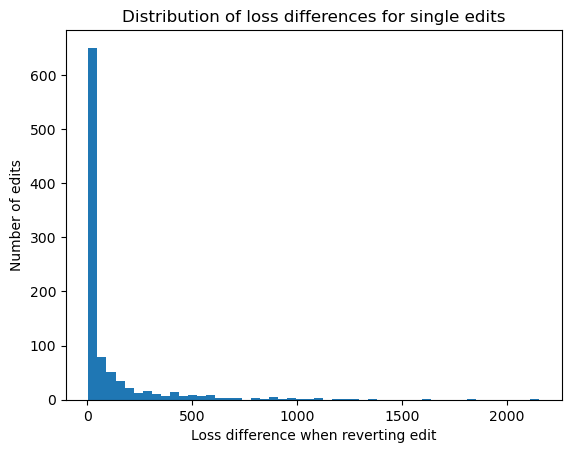

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.hist(all_values, bins=50)
plt.title("Distribution of loss differences for single edits")
plt.xlabel("Loss difference when reverting edit")
plt.ylabel("Number of edits")
plt.show()

In [12]:
# full sequence
X = torch.load("/scratch1/smaruj/ledidi_targets/constant_boundary_background/X.pt", weights_only=True, map_location=device)

In [13]:
bin_size = 2048
cropping_applied = 64
padding_bins = 2

slice_0_bins = [256]
slice_0_start = (min(slice_0_bins) + cropping_applied - padding_bins) * bin_size
slice_0_end = (max(slice_0_bins) + 1 + cropping_applied + padding_bins) * bin_size

In [14]:
X_no_prunning = X.clone()
X_no_prunning[:,:,slice_0_start:slice_0_end] = X_hat

In [15]:
X_with_prunning = X.clone()
X_with_prunning[:,:,slice_0_start:slice_0_end] = X_hat_prunned

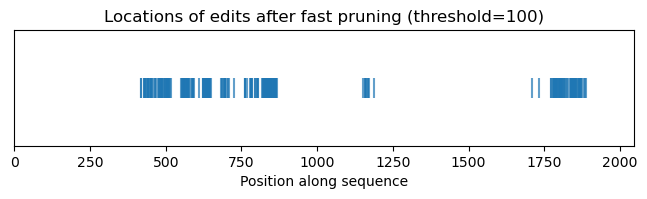

In [17]:
import matplotlib.pyplot as plt

# Suppose your sequence length is L
L = 2048

positions = list(diff_idxs)
corrected_positions = [pos-4048 for pos in positions]
plt.figure(figsize=(8, 1.5))
plt.scatter(corrected_positions, [1]*len(corrected_positions), marker='|', s=200, alpha=0.7)
plt.xlim(0, L)
plt.yticks([])
plt.title(f"Locations of edits after fast pruning (threshold={100})")
plt.xlabel("Position along sequence")
plt.show()

In [18]:
model.eval()
with torch.no_grad():
    pred_no_pruning = model(X_no_prunning)
    pred_with_pruning = model(X_with_prunning)

In [19]:
matrix_to_plot_no_pruning = from_upper_triu(pred_no_pruning[0, 0, :], matrix_len=512, num_diags=2)

In [20]:
matrix_to_plot_with_pruning = from_upper_triu(pred_with_pruning[0, 0, :], matrix_len=512, num_diags=2)

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 800x800 with 0 Axes>

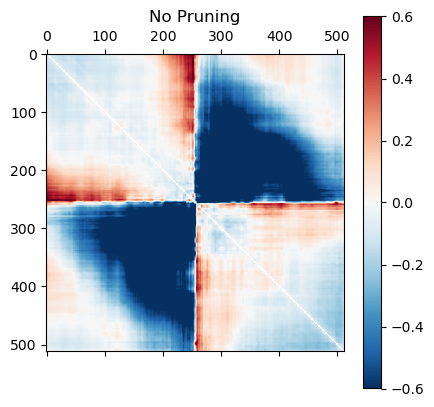

In [22]:
width=5
height=5
vmin = -0.6
vmax = 0.6
palette="RdBu_r"

plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot_no_pruning, cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title('No Pruning')

plt.show()

<Figure size 800x800 with 0 Axes>

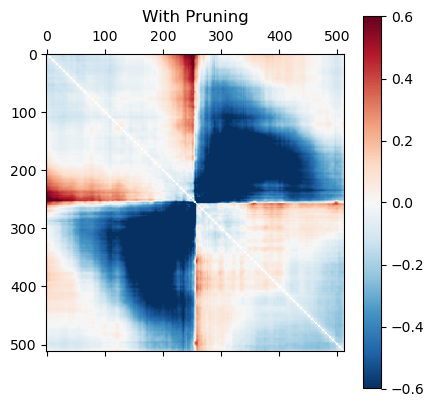

In [23]:
width=5
height=5
vmin = -0.6
vmax = 0.6
palette="RdBu_r"

plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot_with_pruning, cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title('With Pruning')

plt.show()

<Figure size 800x800 with 0 Axes>

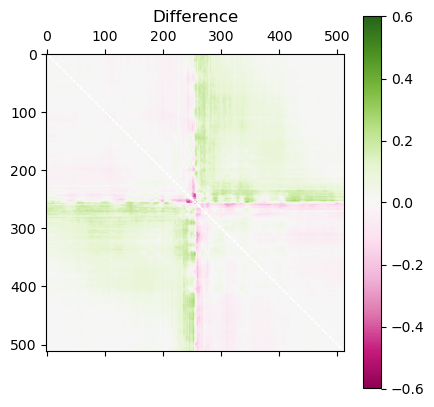

In [24]:
width=5
height=5
vmin = -0.6
vmax = 0.6
palette="PiYG"

plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot_with_pruning-matrix_to_plot_no_pruning, cmap='PiYG', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title('Difference')

plt.show()